In [1]:
import random 
import matplotlib.pyplot as plt
def run_bb84(n, noise_probability=0.0, eve = False):
    
    #----Alice----
    bits_a = [random.randint(0,1) for _ in range (n)]
    basis_a = [random.choice(['+', 'x']) for _ in range (n)]
    
    
    #----Bob----
    basis_b = [random.choice(['+','x']) for _ in range (n)]
    bits_b = []
    
    
    #----Transmission----
    for i in range (n):
        
        if eve :
            #----Eve chooses basis----
            basis_eve = random.choice(['+','x'])
            
            
            #----Eve Measures----
            if basis_eve == basis_a[i]:
                eve_bit = bits_a[i]
            else :
                eve_bit = random.randint(0,1)
            
            #----Bob Measures Eve's qubit
            if basis_b[i] == basis_eve:
                bob_bit  = eve_bit
            else :
                bob_bit = random.randint(0,1)
        
        else :
            #----Normal Transmission----
            if basis_b[i] == basis_a[i]:
                bob_bit = bits_a[i]
            else :
                bob_bit = random.randint(0,1)
        
        bits_b.append(bob_bit)
    
    #----Channel Noise----
    for i in range(n):
        if random.random() < noise_probability:
            bits_b[i] = 1 - bits_b[i]
        
        
        
    #----Shifting----
    key_a =[]
    key_b =[]
    for i in range (n):
        if basis_a[i] == basis_b[i]:
            key_a.append(bits_a[i])
            key_b.append(bits_b[i])
            
    #----Qber Calculation----     
    error =0
    for i in range (len(key_a)):
        if key_a[i] != key_b[i]:
            error +=1
    if len(key_a) > 0:
        qber = error/len(key_a)
    else :
        qber =0
    
    
    #----Key Rate----
    correct_bits = sum(1 for i in range(len(key_a)) if key_a[i] == key_b[i])
    key_rate = correct_bits / n
    
    return qber ,key_rate, len(key_a)
    
    
    
    

In [2]:
n=1000
trials =30

noise_probability = [0.0, 0.025, 0.05,0.075 ,0.1,0.125, 0.15,0.175, 0.2]
qber_normal =[]
qber_eve = []
keyrate_normal=[]
keyrate_eve=[]

for noise in noise_probability:
    
    total_q1 = total_q2 = 0
    total_k1 = total_k2 = 0

    for _ in range(trials):
        q1, k1, _ = run_bb84(n, noise, False)
        q2, k2, _ = run_bb84(n, noise, True)

        total_q1 += q1
        total_q2 += q2

        total_k1 += k1
        total_k2 += k2

    qber_normal.append(total_q1 / trials)
    qber_eve.append(total_q2 / trials)

    keyrate_normal.append(total_k1 / trials)
    keyrate_eve.append(total_k2 / trials)

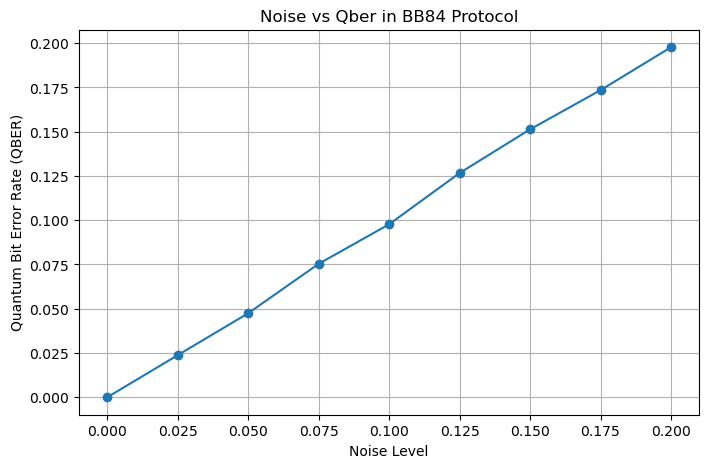

In [3]:
#----Noise vs Qber in BB84 Protocol----


plt.figure(figsize=(8,5))
plt.plot(noise_probability,qber_normal,marker='o')
plt.grid(True)
plt.xlabel("Noise Level")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("Noise vs Qber in BB84 Protocol")
plt.show()

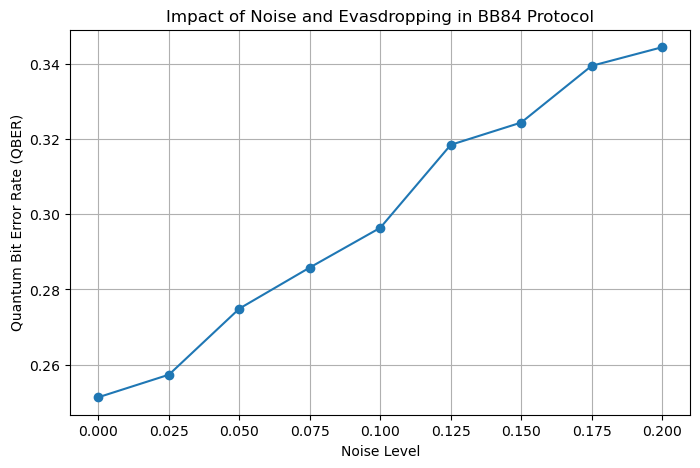

In [4]:
#----Impact of Evasdropping in BB84 Protocol----



plt.figure(figsize=(8,5))
plt.plot(noise_probability,qber_eve, marker='o')

plt.grid(True)
plt.xlabel("Noise Level")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("Impact of Evasdropping in BB84 Protocol")

plt.show()

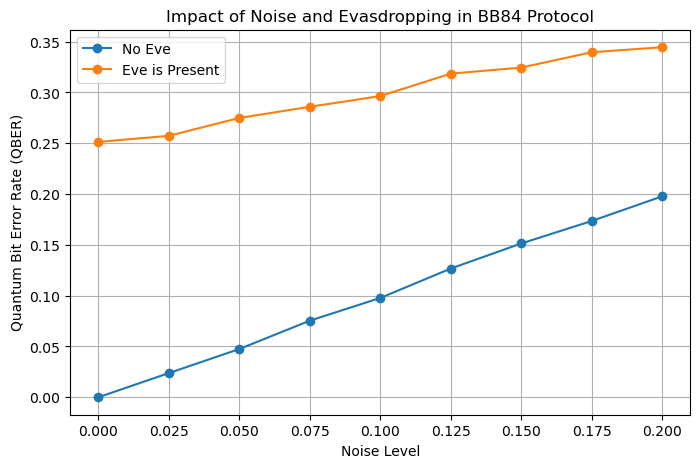

In [5]:
#----Impact of Noise and Evasdropping in BB84 Protocol----



plt.figure(figsize=(8,5))
plt.plot(noise_probability,qber_normal,marker='o',label ="No Eve")
plt.plot(noise_probability,qber_eve, marker='o', label = "Eve is Present")
plt.grid(True)
plt.xlabel("Noise Level")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("Impact of Noise and Evasdropping in BB84 Protocol")
plt.legend()
plt.show()

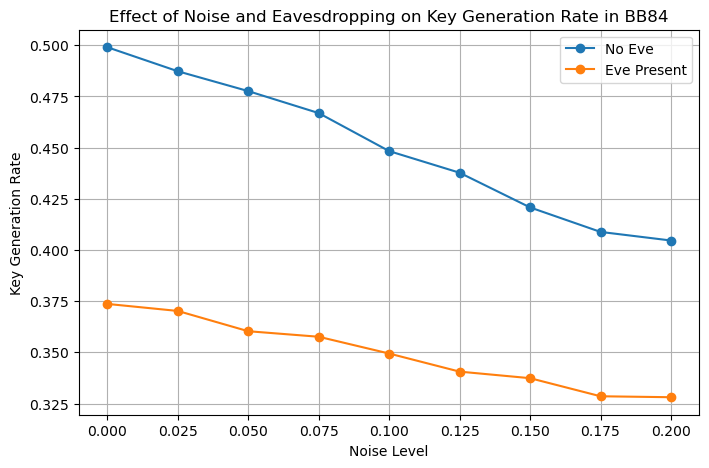

In [6]:
#----Effect of Noise and Eavesdropping on Key Generation Rate in BB84----



plt.figure(figsize=(8,5))

plt.plot(noise_probability, keyrate_normal, marker='o', label="No Eve")
plt.plot(noise_probability, keyrate_eve, marker='o', label="Eve is Present")

plt.grid(True)
plt.xlabel("Noise Level")
plt.ylabel("Key Generation Rate")
plt.title("Effect of Noise and Eavesdropping on Key Generation Rate in BB84")

plt.legend()
plt.show()